In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df_raw = pd.read_csv("resultados.csv")
print(f'Filas cargadas: {len(df_raw)}')
df_raw.head()

Filas cargadas: 1099


,alg_name,array_size,k_value,threshold,num_threads,mean_time,std_time
0,mergesort_seq,1048576,-1,16,1,0.077556,0.001607
1,mergesort_seq,1048576,-1,64,1,0.078603,0.001490
2,mergesort_seq,1048576,-1,256,1,0.076217,0.000679
3,mergesort_seq,1048576,-1,1024,1,0.074499,0.000922
4,mergesort_seq,1048576,-1,4096,1,0.071901,0.000705


In [4]:
# Limpieza de datos
df = df_raw.replace([np.inf, -np.inf], np.nan).dropna(subset=['mean_time']).copy()

invalid_time = df[df['mean_time'] <= 0].copy()
if len(invalid_time) > 0:
    print(f'Se encontraron {len(invalid_time)} filas con mean_time <= 0. Descartadas.')

df = df[df['mean_time'] > 0].copy()

parallel_algs = ['mergesort_par', 'kway_par', 'kway_ranks', 'kway_full']
sequential_algs = ['mergesort_seq', 'kway_seq']

df_par = df[df['alg_name'].isin(parallel_algs)].copy()
df_seq = df[df['alg_name'].isin(sequential_algs)].copy()

print(f'Filas totales después de limpieza: {len(df)}')
print(f'Filas para algoritmos paralelos: {len(df_par)}')
print(f'Filas para algoritmos secuenciales: {len(df_seq)}')

Se encontraron 1 filas con mean_time <= 0. Descartadas.
Filas totales después de limpieza: 1098
Filas para algoritmos paralelos: 979
Filas para algoritmos secuenciales: 119


In [5]:
# Baseline secuencial
baseline_seq = df_seq[(df_seq['alg_name'] == 'mergesort_seq')].groupby('array_size').min()
baseline_seq = baseline_seq.rename(columns={'mean_time': 'baseline_time'})

Threshold óptimo para mergesort_par (array_size=2^26, num_threads=8): 1024


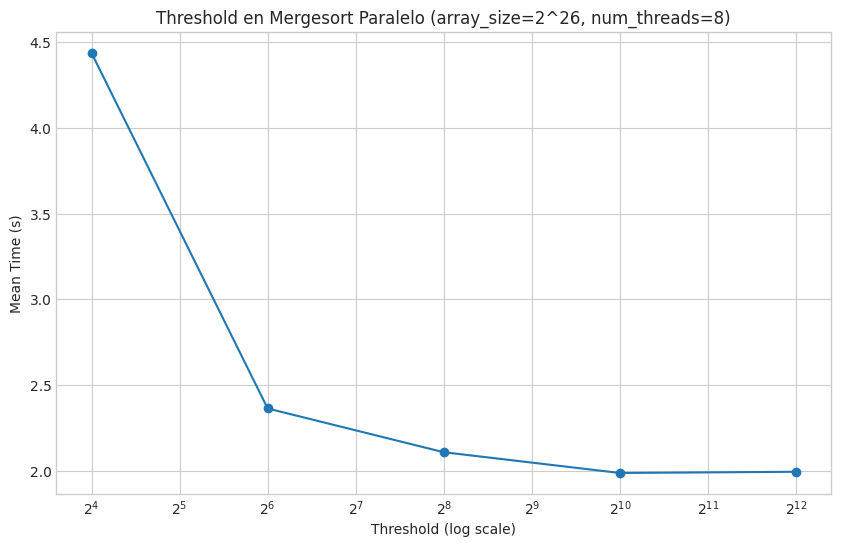

In [6]:
# Estudio de granularidad (threshold)
filtro = (df_par['alg_name'] == 'mergesort_par') & (df_par['array_size'] == (2**26)) & (df_par['num_threads'] == 8)
threshold_df = df_par[(df_par['alg_name'] == 'mergesort_par') & (df_par['array_size'] == (2**26)) & (df_par['num_threads'] == 8)].copy()
threshold_df = threshold_df.sort_values('threshold')

optimal_threshold = threshold_df.loc[threshold_df['mean_time'].idxmin(), 'threshold']
print(f'Threshold óptimo para mergesort_par (array_size=2^26, num_threads=8): {optimal_threshold}')
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['threshold'], threshold_df['mean_time'], marker='o')
plt.xscale('log', base=2)
plt.xlabel('Threshold (log scale)')
plt.ylabel('Mean Time (s)')
plt.title('Threshold en Mergesort Paralelo (array_size=2^26, num_threads=8)')
plt.grid(True)


K-value óptimo para k-way paralelo (array_size=2^26, num_threads=8, threshold=2^10): 16


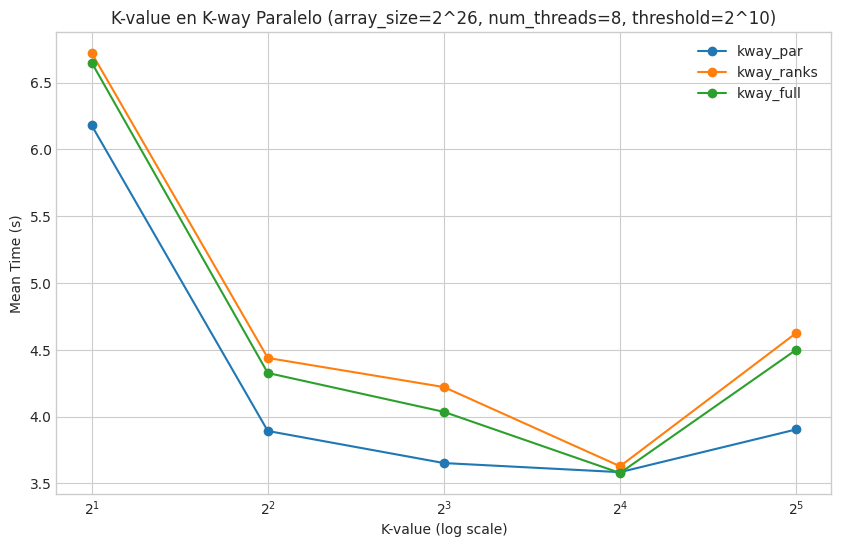

In [7]:
# Estudio de k-value

filtro = (df_par['array_size'] == (2**26)) & (df_par['num_threads'] == 8) & (df_par['k_value'] > 0) & (df_par['threshold'] == 2**10)

kvalue_df = df_par[filtro].copy()
kvalue_df = kvalue_df.sort_values('k_value')

plt.figure(figsize=(10, 6))

# iteramos por los 3 kway
for alg in ['kway_par', 'kway_ranks', 'kway_full']:
    df_alg = kvalue_df[kvalue_df['alg_name'] == alg]
    plt.plot(df_alg['k_value'], df_alg['mean_time'], marker='o', label=alg)

optimal_k = kvalue_df.loc[kvalue_df['mean_time'].idxmin(), 'k_value']
print(f'K-value óptimo para k-way paralelo (array_size=2^26, num_threads=8, threshold=2^10): {optimal_k}')

plt.xscale('log', base=2)
plt.xlabel('K-value (log scale)')
plt.ylabel('Mean Time (s)')
plt.title('K-value en K-way Paralelo (array_size=2^26, num_threads=8, threshold=2^10)')
plt.legend()
plt.grid(True)

In [11]:
# Calculo de metricas

df_merge = pd.merge(df_par, baseline_seq[['baseline_time']], on='array_size', how='left')
df_merge['speedup'] = df_merge['baseline_time'] / df_merge['mean_time']
df_merge['efficiency'] = df_merge['speedup'] / df_merge['num_threads']

N_obj = 2**26

filtro_plot = (
    (df_merge['array_size'] == N_obj) &
    (df_merge['threshold'] == optimal_threshold) &
    (
        (df_merge['k_value'] == optimal_k) | (df_merge['alg_name'] == 'mergesort_par')
    )
)

df_plot = df_merge[filtro_plot].copy()


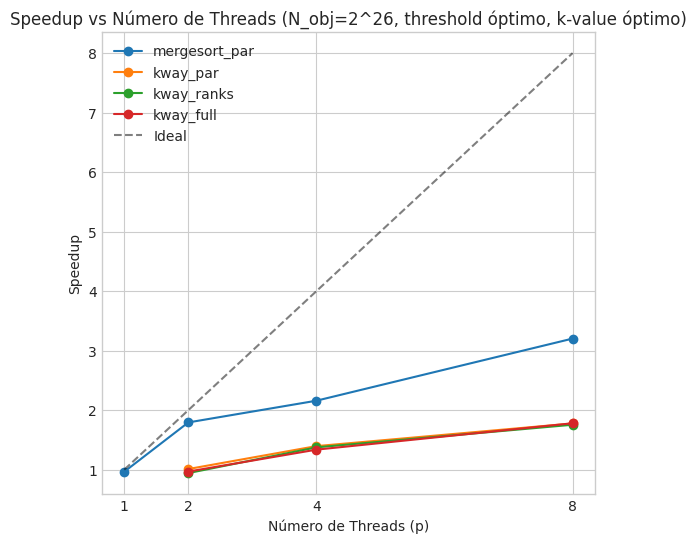

In [13]:
# Grafico de speedup y eficiencia

plt.figure(figsize=(14, 6))

# speedup
plt.subplot(1, 2, 1)
for alg in parallel_algs:
    df_alg = df_plot[df_plot['alg_name'] == alg].sort_values('num_threads')
    if not df_alg.empty:
        plt.plot(df_alg['num_threads'], df_alg['speedup'], marker='o', label=alg)

# Speedup ideal
plt.plot([1, 2, 4, 8], [1, 2, 4, 8], 'k--', label='Ideal', alpha=0.5)

plt.xticks([1, 2, 4, 8])
plt.xlabel('Número de Threads (p)')
plt.ylabel('Speedup')
plt.title('Speedup vs Número de Threads (N_obj=2^26, threshold óptimo, k-value óptimo)')
plt.legend()
plt.grid(True)



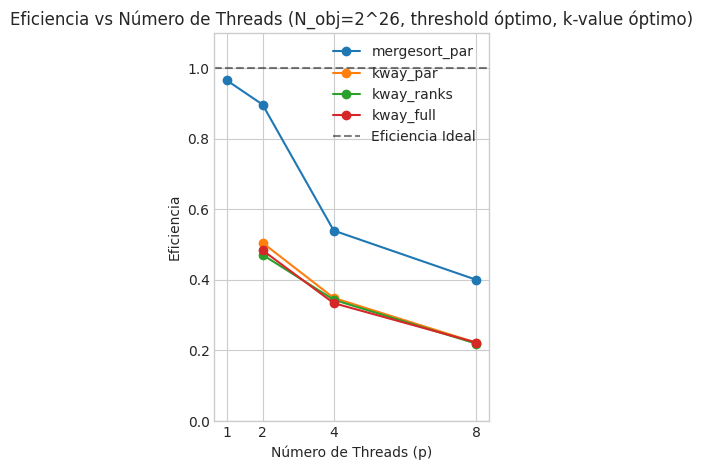

In [14]:
# eficiencia
plt.subplot(1, 2, 2)
for alg in parallel_algs:
    df_alg = df_plot[df_plot['alg_name'] == alg].sort_values('num_threads')
    if not df_alg.empty:
        plt.plot(df_alg['num_threads'], df_alg['efficiency'], marker='o', label=alg)

plt.axhline(1, color='k', linestyle='--', label='Eficiencia Ideal', alpha=0.5)
plt.ylim(0, 1.1)

plt.xticks([1, 2, 4, 8])
plt.xlabel('Número de Threads (p)')
plt.ylabel('Eficiencia')
plt.title('Eficiencia vs Número de Threads (N_obj=2^26, threshold óptimo, k-value óptimo)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

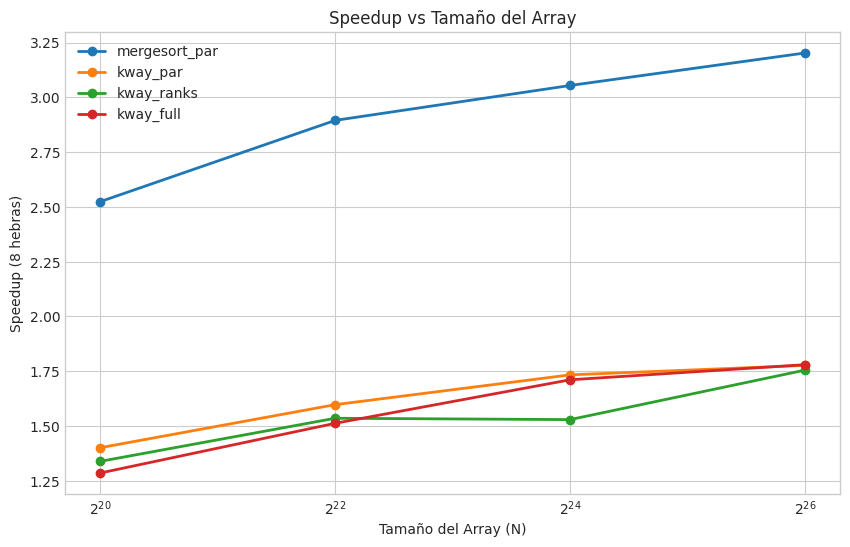

In [17]:
# Como afecta el tamaño del array al speedup y eficiencia

filtro_tamano = (
    (df_merge['num_threads'] == 8) &
    (df_merge['threshold'] == optimal_threshold) &
    (
        (df_merge['k_value'] == optimal_k) | (df_merge['alg_name'] == 'mergesort_par')
    )
)

df_tamano = df_merge[filtro_tamano].copy()

plt.figure(figsize=(10, 6))

for alg in parallel_algs:
    df_alg = df_tamano[df_tamano['alg_name'] == alg].sort_values('array_size')
    if not df_alg.empty:
        plt.plot(df_alg['array_size'], df_alg['speedup'], marker='o',linewidth=2, label=alg)


plt.xscale('log', base=2)
plt.xticks([2**20, 2**22, 2**24, 2**26], labels=['$2^{20}$', '$2^{22}$', '$2^{24}$', '$2^{26}$'])

plt.xlabel('Tamaño del Array (N)')
plt.ylabel('Speedup (8 hebras)')
plt.title('Speedup vs Tamaño del Array')
plt.legend()
plt.grid(True)
plt.show()


